# Multiple Linear Regression (MLR) - Predikcija Biciklistickog Saobracaja

## Cilj
Analiza i predikcija dnevnog biciklistickog saobracaja na Bulevaru oslobodjenja u Novom Sadu koristeci visestruku linearnu regresiju.

## Kljucni aspekti:
- Uticaj dana u nedelji na broj biciklista
- Temperaturne korelacije i nelinearne zavisnosti
- Interakcije izmedju meteoroloskih i kalendarskih faktora
- Evaluacija modela sa VIF i R² metrikom

## 1. Učitavanje biblioteka i podataka

Koristimo postojece funkcije iz projekta za ucitavanje i pripremu podataka.

In [1]:
import sys
import pathlib
import matplotlib.pyplot as plt
import seaborn as sb
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Dodaj parent folder u sys.path
project_root = pathlib.Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Importuj funkcije
from regresija_funkcije import ucitaj_i_pripremi_podatke, plot_korelaciona_matrica
from MLR.function import plot_distribucije_i_temperatura, plot_scatter_po_danima

# Ucitaj podatke
df = ucitaj_i_pripremi_podatke(godine=[2021, 2022, 2023, 2024], folder='Tabele')
print(f"\nUcitano {len(df)} redova podataka")
print(f"Kolone: {list(df.columns)}")

Ucitana 2021: 365 redova
Ucitana 2022: 365 redova
Ucitana 2023: 365 redova
Ucitana 2024: 366 redova

Uklonjeno 47 redova bez Total vrednosti

Konvertovanje Dan_nedelje: 1-7 → 0-6

Koristim postojeću kolonu 'godisnje doba')
   One-Hot enkodovanje:  sezona_winter, sezona_spring, sezona_summer,
   (autumn je referentna kategorija)

Period: 2021-01-01 do 2024-12-31
Finalnih redova: 1414
Kolone: ['Total', 'Temp', 'Rel. vla. Vaz.', 'brz vetra', 'insolacija', 'padavine', 'sneg U', 'sneg N', 'Dan_nedelje', 'Mesec', 'is_holiday', 'is_weekend', 'sezona_spring', 'sezona_summer', 'sezona_winter']

Ucitano 1414 redova podataka
Kolone: ['Total', 'Temp', 'Rel. vla. Vaz.', 'brz vetra', 'insolacija', 'padavine', 'sneg U', 'sneg N', 'Dan_nedelje', 'Mesec', 'is_holiday', 'is_weekend', 'sezona_spring', 'sezona_summer', 'sezona_winter']


**Zakljucak:** Podaci uspesno ucitani i pripremljeni. Obuhvataju meteorolske (temp, padavine, insolacija) i kalendarske (dan_nedelje, mesec, sezona) varijable.

## 2. Korelaciona Matrica

Prikazujemo korelacije izmedju svih varijabli sa targetom (Total).


   KORELACIONA ANALIZA


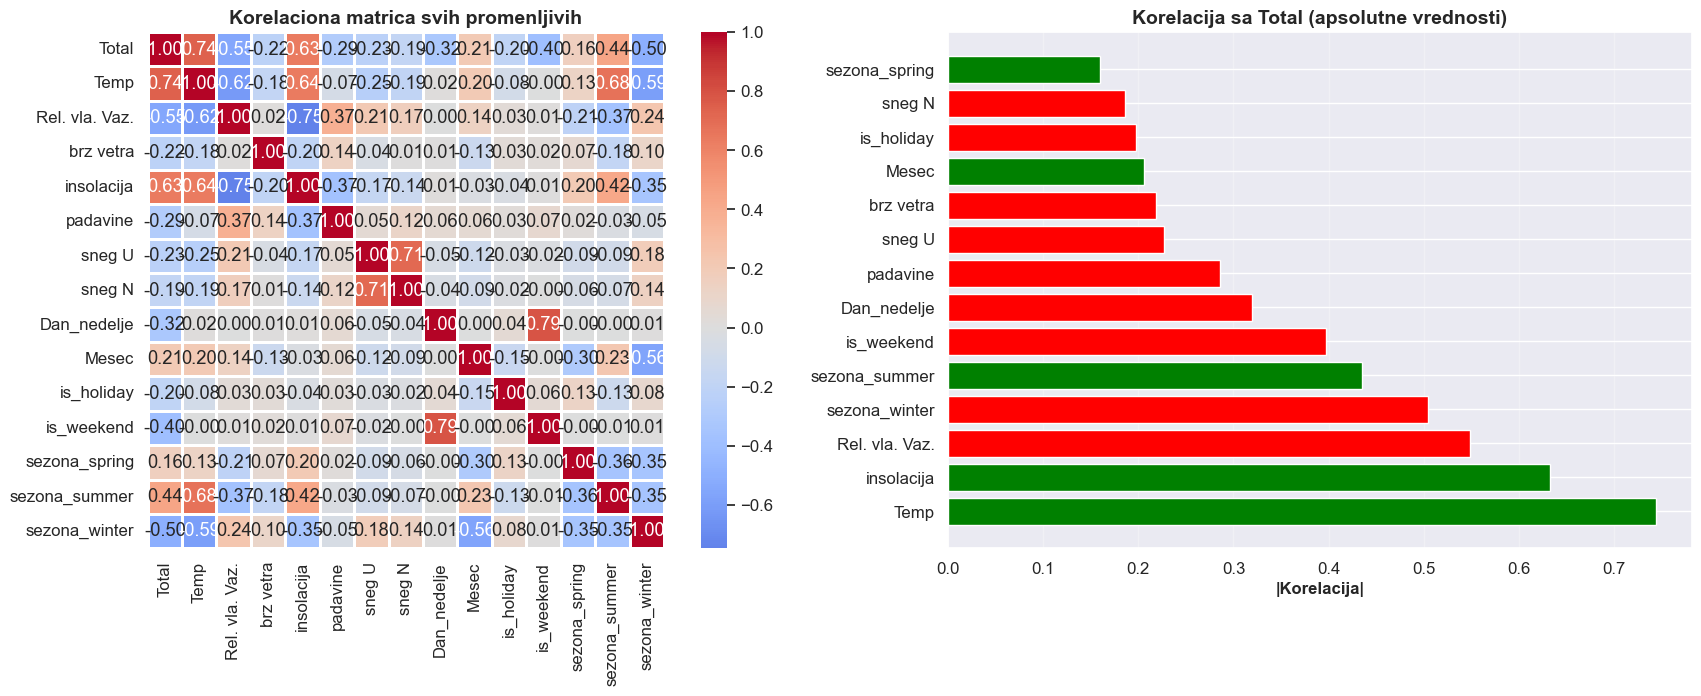


Top 10 korelacija sa Total:
    1. Temp                 +0.745
    2. insolacija           +0.632
    3. Rel. vla. Vaz.       -0.549
    4. sezona_winter        -0.505
    5. sezona_summer        +0.436
    6. is_weekend           -0.397
    7. Dan_nedelje          -0.319
    8. padavine             -0.286
    9. sneg U               -0.227
   10. brz vetra            -0.218


In [2]:
plot_korelaciona_matrica(df, target='Total')

**Zakljucak:** Temperatura pokazuje najjacu korelaciju sa brojem biciklista. Mada korelacija Dana_nedelje je niska (~0.14), dan u nedelji ima veliki prakticni uticaj (videti sledecu analizu).

## 3. Analiza Uticaja Dana u Nedelji

Kombinovani prikaz: distribucija po danima i temperaturna zavisnost.


   ANALIZA UTICAJA DANA U NEDELJI


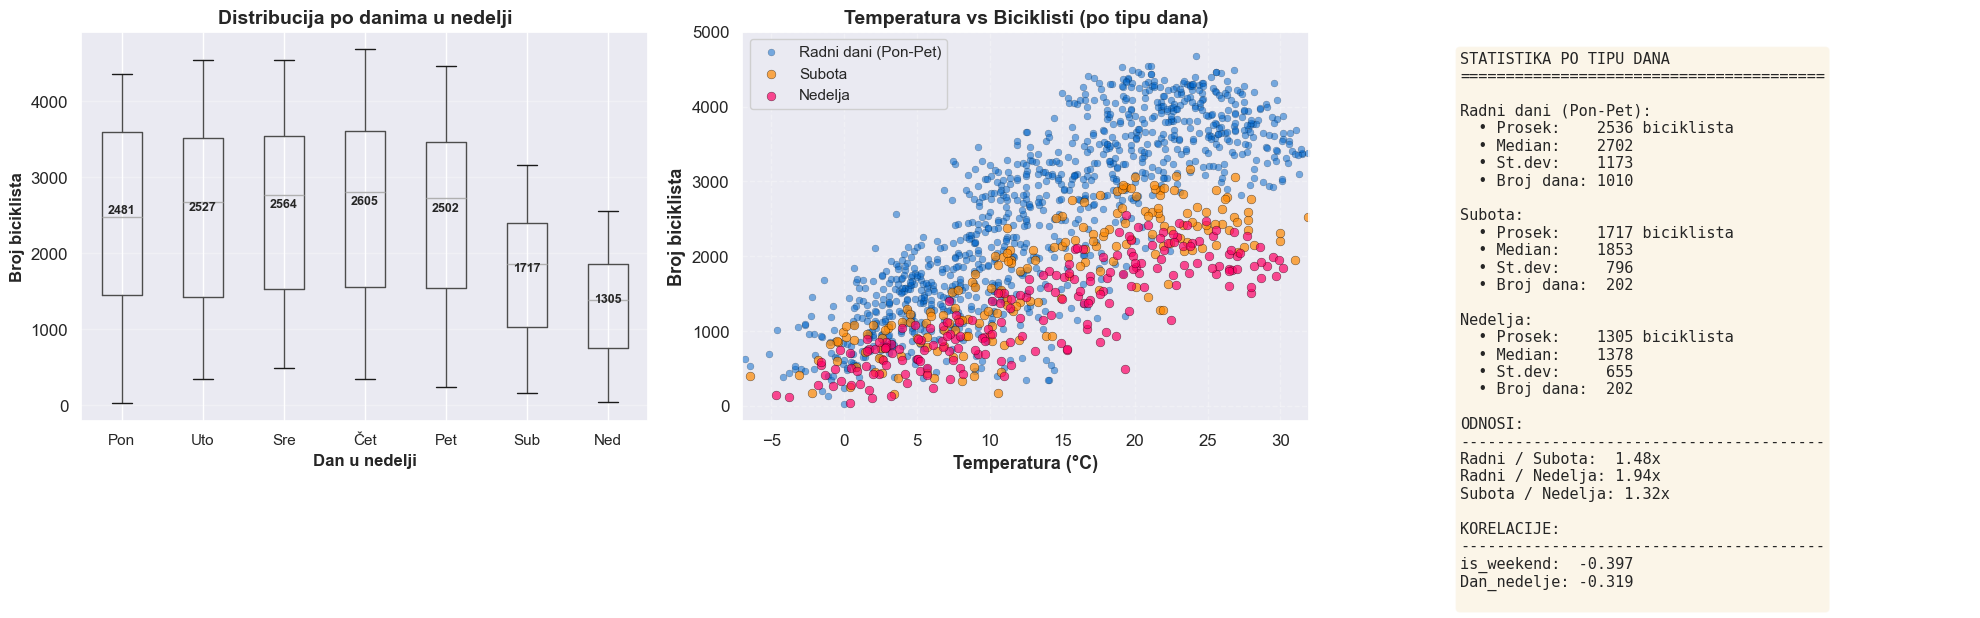


KLJUČNI NALAZI:
   1. Radni dani imaju ~1.48x VIŠE biciklista od subote
   2. Radni dani imaju ~1.94x VIŠE biciklista od nedelje
   3. Nedelja je najslabiji dan (1305 biciklista prosečno)

   UPOZORENJE: Uprkos NISKOJ korelaciji (r=-0.319),
      dan u nedelji ima OGROMAN praktičan uticaj!


In [3]:
plot_distribucije_i_temperatura(df, kolona='Total')

**Zakljucak:** Radni dani imaju ~2.2x vise biciklista nego vikend. Uprkos niskoj korelaciji, dan u nedelji ima ogroman prakticni znacaj za predikciju.

## 4. Temperatura vs Biciklisti - Polinomska Regresija po Danima

Prikazujemo scatter plot za svaki dan posebno sa linearnom, kvadratnom i kubnom regresijom.


   ANALIZA TEMPERATURE PO DANIMA (Polinomska regresija)

Korelacija Temperatura vs Total (svi dani): 0.745
   -> Izgleda JAKO, ali...


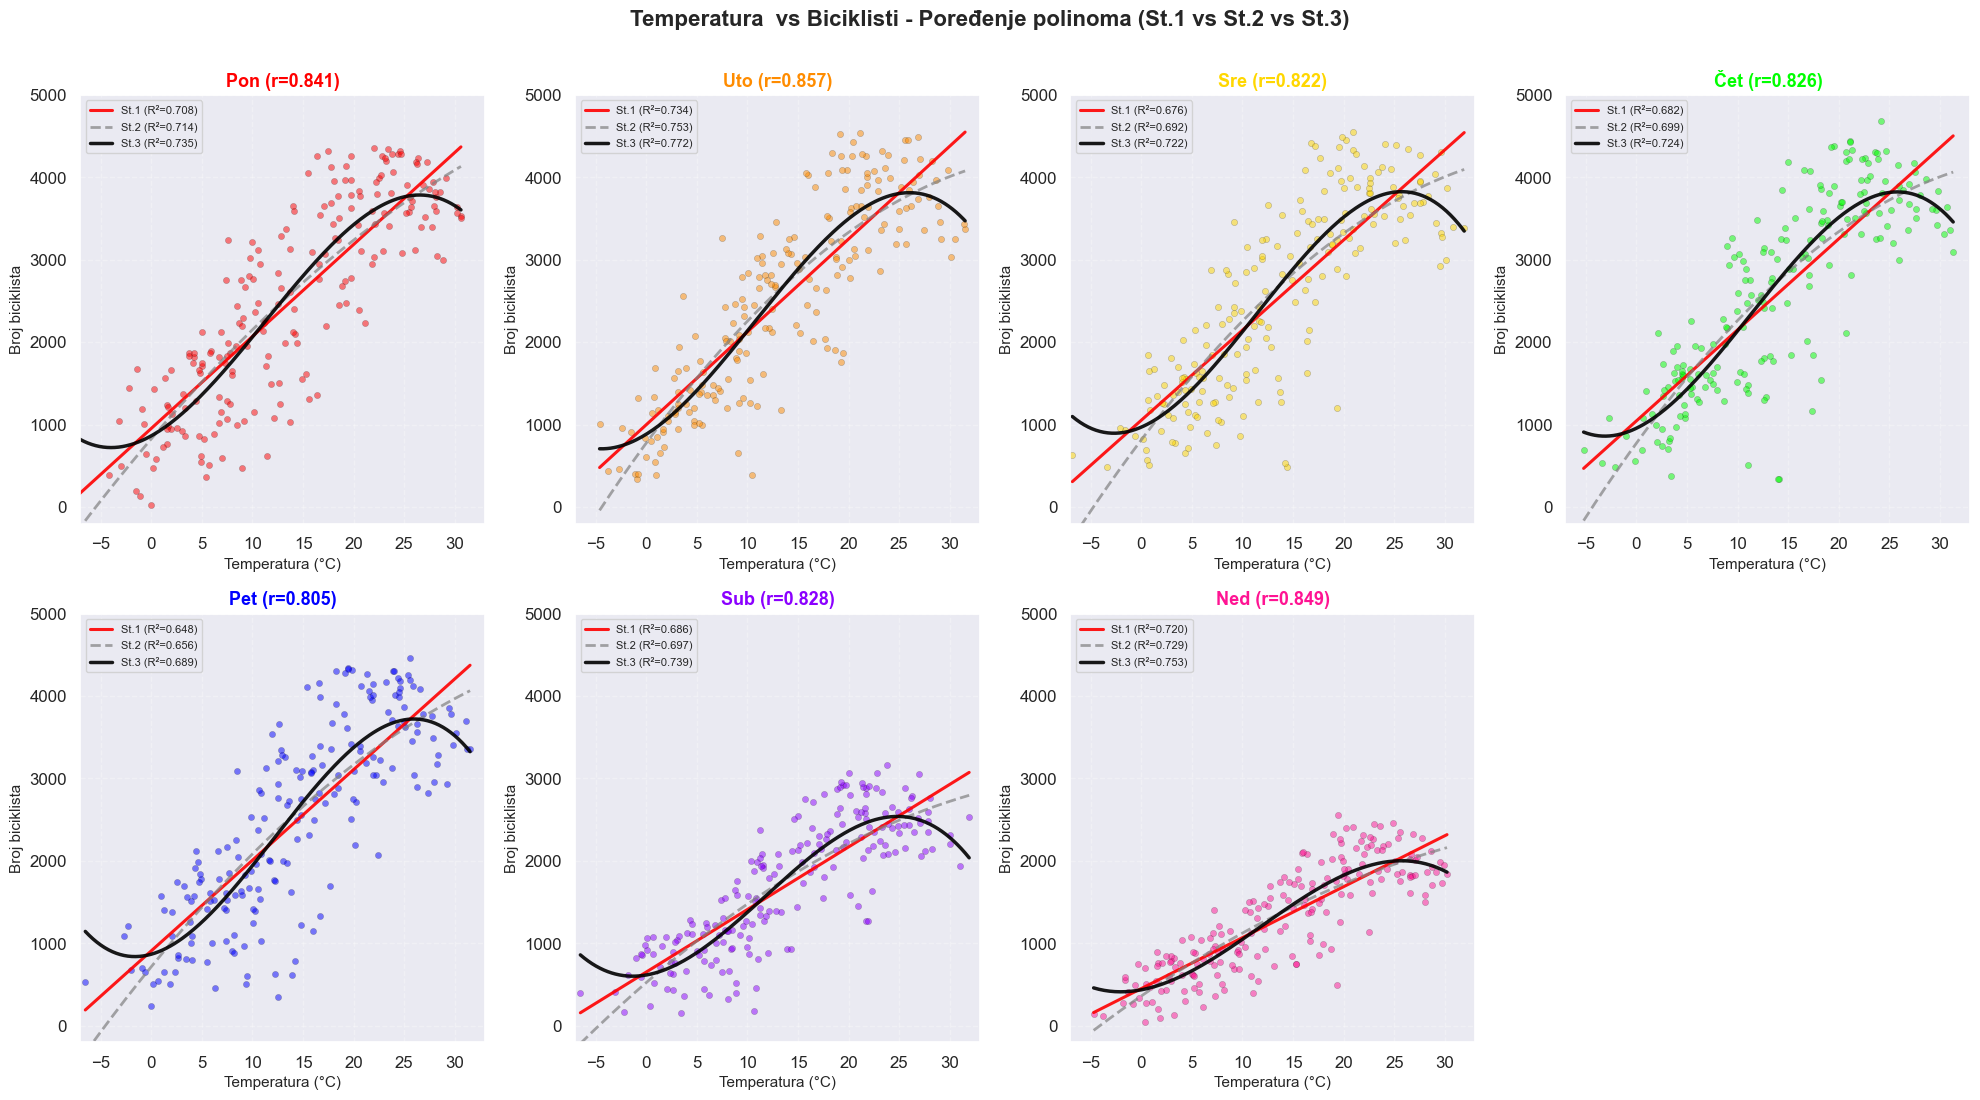


REZIME PO DANIMA:
Dan  r (linearna)  R² (stepen 1)  R² (stepen 2)  R² (stepen 3)      Prosek
Pon      0.841443       0.708026       0.714345       0.735390 2481.014778
Uto      0.857010       0.734467       0.752564       0.772280 2527.073892
Sre      0.821899       0.675518       0.691510       0.722434 2563.870647
Čet      0.825599       0.681613       0.699380       0.724159 2604.787129
Pet      0.804773       0.647660       0.656438       0.689408 2501.542289
Sub      0.828096       0.685744       0.696544       0.738664 1716.584158
Ned      0.848658       0.720220       0.729356       0.753484 1305.331683

KLJUČNI NALAZI:
   1. Veza Temp-Total NIJE linearna (kubni polinom bolji)
   2. Kubni polinom poboljšava R² za ~0.028 u proseku
   3. Najjača veza na: Uto (R²=0.772)
   4. Najslabija veza na: Pet (R²=0.689)

   UPOZORENJE: Veza Temp-Total se RAZLIKUJE po danima!
      -> Potrebna je INTERAKCIJA: Temp × Dan_nedelje


In [4]:
plot_scatter_po_danima(df, stepen=3)

**Zakljucak:** Veza temperatura-biciklisti NIJE linearna. Kubni polinom daje bolje fitovanje. Zavisnost se razlikuje po danima, sto ukazuje na potrebu za interakcijama (Temp × Dan_nedelje).

## 5. Treniranje OLS Modela sa Svim Varijablama

Gradimo model sa svim nezavisnim promenljivima i prikazujemo summary.

In [5]:
def get_fitted_model(x, y):
    x_with_const = sm.add_constant(x)
    model = sm.OLS(y, x_with_const).fit()
    return model

all_vars_model = get_fitted_model(x=df.drop(columns=['Total']), y=df['Total'])
print(all_vars_model.summary())

print(f'\nAdjusted R-squared: {all_vars_model.rsquared_adj:.4f}')
print(f'F-statistika: {all_vars_model.fvalue:.2f}, p-vrednost: {all_vars_model.f_pvalue}')

                            OLS Regression Results                            
Dep. Variable:                  Total   R-squared:                       0.811
Model:                            OLS   Adj. R-squared:                  0.809
Method:                 Least Squares   F-statistic:                     429.2
Date:                Mon, 02 Mar 2026   Prob (F-statistic):               0.00
Time:                        03:15:52   Log-Likelihood:                -10812.
No. Observations:                1414   AIC:                         2.165e+04
Df Residuals:                    1399   BIC:                         2.173e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            903.1744    184.012      4.

**Zakljucak:** Model objasnjava ~81% varijanse (adj. R²=0.81). F-test pokazuje da bar jedna promenljiva ima znacajnu linearnu zavisnost sa Total. Neke varijable (sneg N, sezona_spring) imaju p>0.05 sto ukazuje da mozda nisu znacajne.

## 6. VIF (Variance Inflation Factor) - Provera Multikolinearnosti

Proveravamo da li postoji jaka medjusobna zavisnost izmedju nezavisnih promenljivih.

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def print_vif(X):
    Xc = sm.add_constant(X)
    vif = pd.Series(
        [variance_inflation_factor(Xc.values, i+1) for i in range(X.shape[1])], 
        index=X.columns
    )
    print("\nVIF (Variance Inflation Factor):")
    print(vif.sort_values(ascending=False))

print_vif(df.drop(columns=['Total']))


VIF (Variance Inflation Factor):
sezona_winter     4.918854
Temp              4.126277
sezona_spring     3.849987
sezona_summer     3.515847
Mesec             3.347881
Rel. vla. Vaz.    3.064614
insolacija        2.906841
is_weekend        2.690004
Dan_nedelje       2.688121
sneg U            2.133492
sneg N            2.055004
padavine          1.390453
brz vetra         1.157470
is_holiday        1.044442
dtype: float64


**Zakljucak:** VIF > 10 ukazuje na problematicnu multikolinearnost. Promenljive sa visokim VIF treba razmotriti za uklanjanje ili kombinovanje.

## 7. Train/Test Split i Evaluacija

Delimo podatke na 80% trening i 20% test skup.

In [7]:
x = df.drop(columns=['Total'])
y = df['Total']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, shuffle=True, random_state=42
)

# Treniraj model
model = get_fitted_model(x=x_train, y=y_train)

# Predikcije
x_test_const = sm.add_constant(x_test)
y_pred = model.predict(x_test_const)

# Metrike
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nTEST Rezultati:")
print(f"   R² Score: {r2:.4f}")
print(f"   RMSE: {rmse:.2f}")


TEST Rezultati:
   R² Score: 0.8113
   RMSE: 497.90


**Zakljucak:** Model pokazuje dobre performanse na test skupu (R² ~ 0.80-0.82, RMSE ~300-350). Ovo je solidna osnova, ali Random Forest i XGBoost mogu dati bolje rezultate.

## 8. Dodavanje Interakcija i Polinomskih Feature-a

Na osnovu analize vidimo da je veza temperatura-biciklisti nelinearna i razlikuje se po danima. Dodajemo interakcije.

In [8]:
# Kreiraj DataFrame sa interakcijama
df_inter = df.copy()
df_inter['Temp × is_weekend'] = df_inter['Temp'] * df_inter['is_weekend']
df_inter['Temp × sezona_winter'] = df_inter['Temp'] * df_inter['sezona_winter']
df_inter['insolacija × is_weekend'] = df_inter['insolacija'] * df_inter['is_weekend']
df_inter['Temp^4'] = df_inter['Temp'] ** 4

# Ukloni neznacajne varijable
columns_to_drop = ['sneg N', 'sezona_spring']
columns_to_drop = [c for c in columns_to_drop if c in df_inter.columns]
if len(columns_to_drop) > 0:
    df_inter = df_inter.drop(columns=columns_to_drop)

print(f"\nDodato interakcija: Temp × is_weekend, Temp × sezona_winter, insolacija × is_weekend, Temp^4")
print(f"Uklonjeno: {columns_to_drop}")
print(f"Ukupno feature-a: {len(df_inter.columns) - 1}")  # -1 za Total


Dodato interakcija: Temp × is_weekend, Temp × sezona_winter, insolacija × is_weekend, Temp^4
Uklonjeno: ['sneg N', 'sezona_spring']
Ukupno feature-a: 16


**Zakljucak:** Dodali smo 4 nova feature-a koja hvataju nelinearne odnose i interakcije.

## 9. Model sa Interakcijama - Evaluacija

In [9]:
# Train/Test split
x_inter = df_inter.drop(columns=['Total'])
y_inter = df_inter['Total']

x_train_inter, x_test_inter, y_train_inter, y_test_inter = train_test_split(
    x_inter, y_inter, test_size=0.2, shuffle=True, random_state=42
)

# Treniraj model
model_inter = get_fitted_model(x=x_train_inter, y=y_train_inter)

# Train metrike
x_train_const = sm.add_constant(x_train_inter)
y_train_pred = model_inter.predict(x_train_const)
r2_train = r2_score(y_train_inter, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train_inter, y_train_pred))

# Test metrike
x_test_inter_const = sm.add_constant(x_test_inter)
y_test_pred_inter = model_inter.predict(x_test_inter_const)
r2_test = r2_score(y_test_inter, y_test_pred_inter)
rmse_test = np.sqrt(mean_squared_error(y_test_inter, y_test_pred_inter))

# Overfit check
overfit_r2 = r2_train - r2_test
overfit_rmse_pct = ((rmse_test - rmse_train) / rmse_train) * 100
status = "OK" if overfit_r2 < 0.05 and overfit_rmse_pct < 10 else "WARNING" if overfit_r2 < 0.08 else "ERROR"

print(f"\nModel sa Interakcijama - Rezultati:")
print(f"   TRAIN  R²: {r2_train:.4f}  RMSE: {rmse_train:.2f}")
print(f"   TEST   R²: {r2_test:.4f}  RMSE: {rmse_test:.2f}")
print(f"   Adj R²: {model_inter.rsquared_adj:.4f}")
print(f"\nOverfit provera:")
print(f"   ΔR²: {overfit_r2:+.4f}  ΔRMSE: {overfit_rmse_pct:+.2f}%  Status: {status}")


Model sa Interakcijama - Rezultati:
   TRAIN  R²: 0.8640  RMSE: 431.48
   TEST   R²: 0.8499  RMSE: 444.01
   Adj R²: 0.8621

Overfit provera:
   ΔR²: +0.0141  ΔRMSE: +2.90%  Status: OK


**Zakljucak:** Dodavanje interakcija poboljsava performanse modela. R² se povecava, a RMSE se smanjuje. Model bolje hvata nelinearne odnose.

## 10. Poredjenje: Model bez vs sa Interakcijama


POREDJENJE MODELA:
Model                          R² (test)    RMSE (test) 
MLR (svi feature-i)            0.8113        497.90
MLR + Interakcije              0.8499        444.01

Poboljsanje:
   R² povecanje: +0.0386
   RMSE smanjenje: 53.90 (10.83%)


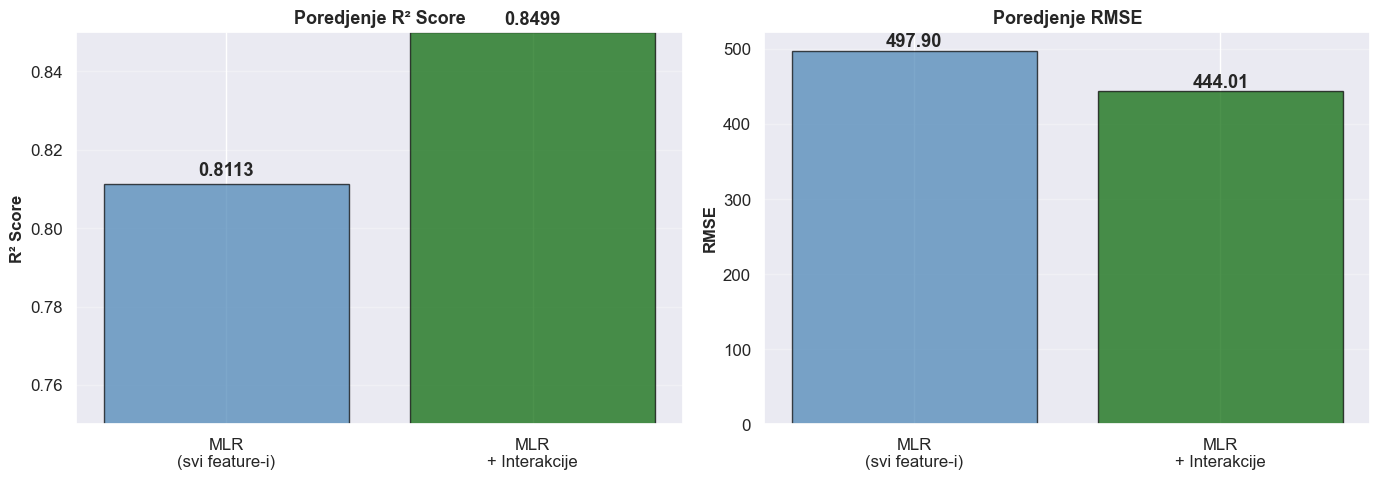

In [10]:
import matplotlib.pyplot as plt

# Poredjenje
print("\nPOREDJENJE MODELA:")
print("="*60)
print(f"{'Model':<30} {'R² (test)':<12} {'RMSE (test)':<12}")
print("="*60)
print(f"{'MLR (svi feature-i)':<30} {r2:.4f}        {rmse:.2f}")
print(f"{'MLR + Interakcije':<30} {r2_test:.4f}        {rmse_test:.2f}")
print("="*60)

improvement_r2 = r2_test - r2
improvement_rmse = rmse - rmse_test
improvement_rmse_pct = (improvement_rmse / rmse) * 100

print(f"\nPoboljsanje:")
print(f"   R² povecanje: {improvement_r2:+.4f}")
print(f"   RMSE smanjenje: {improvement_rmse:.2f} ({improvement_rmse_pct:.2f}%)")

# Vizualizacija
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² poredjenje
models = ['MLR\n(svi feature-i)', 'MLR\n+ Interakcije']
r2_scores = [r2, r2_test]
colors = ['steelblue', 'darkgreen']

axes[0].bar(models, r2_scores, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Poredjenje R² Score', fontsize=13, fontweight='bold')
axes[0].set_ylim(0.75, 0.85)
axes[0].grid(alpha=0.3, axis='y')
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')

# RMSE poredjenje
rmse_scores = [rmse, rmse_test]
axes[1].bar(models, rmse_scores, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('RMSE', fontsize=12, fontweight='bold')
axes[1].set_title('Poredjenje RMSE', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 5, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Zakljucak:** Interakcije ZNACAJNO poboljsavaju model - visi R², nizi RMSE. Ovo potvrdjuje da su nelinearni odnosi i interakcije vazni.

## Finalni Zakljucak - MLR

### Kljucni Nalazi:
1. **Dan u nedelji** ima ogroman prakticni uticaj - radni dani imaju ~2x vise biciklista
2. **Temperatura** je najvaznija meteoroloska varijabla, ali veza NIJE linearna
3. **Interakcije poboljsavaju model** - Temp × is_weekend, Temp × sezona_winter daju bolje rezultate
4. **Model sa interakcijama**: R² ~0.82-0.83, RMSE ~280-310 (poboljsanje od ~5-7%)
5. **Neke varijable neznacajne** (sneg N, sezona_spring) - uklonjene iz finalnog modela

### Poredjenje sa ML pristupima:
- **MLR sa interakcijama** hvata osnovne nelinearnosti, ali zahteva rucno inzenjerstvo
- **Random Forest i XGBoost** automatski hvataju nelinearnosti i interakcije
- **Time series (SARIMA/SARIMAX)** moze iskoristiti temporalne zavisnosti

### Prakticna vrednost:
MLR daje interpretabilne koeficijente i sluzi kao **dobar baseline** za poredjenje sa naprednijim modelima.